#1&rpar; What is Neo4J?

Neo4J is a Native graph database that uses the property graph model. Instead of tables with rows and columns, it stores data as Nodes which describe the entities of a domain and edges which describes the relationships connecting them.  It is designed to handle large amounts of data efficiently and can be deployed as a standalone server or in a fault-tolerant cluster. Neo4j is particularly useful when you need to represent and query complex relationships in your data, such as social networks, recommendation systems, and fraud detection. It's property graph approach enhances traversal performance and operational runtime, making it a great choice for applications where relationships are key.

## 1.1 What does Neo4J do natively and why does the idea of native matter?

Neo4j features both Native Graph Storage and Native Graph Processing.

Native Storage (index-free Adjacency): Under the hood, Neo4J does not use standard relational indexes to find connected data. Instead, every node physically contains direct memory pointers to its adjacent nodes.

*   **Why it matters**: In a SQL database, finding relationships require heavy, expensive `JOIN` operations that slow down exponentially as the data grows. With Neo4j's index-free adjacency, traversing a relationship is an `O(1) `operation. The database simply follows a memory pointer, meaning it can hop through millions of connections per second, regarding of how massive the overall database becomes. By handling graph data natively, Neo4j can effectively support ACID transactions, runtime failover, and a rich ecosystem of tools that enhance its capabilities. This native design translates to better performance, particularly for applications that rely heavily on relationship-centric queries.



#2&rpar; Install and set up Neo4J

Following the steps https://colab.research.google.com/drive/15KBakWm1WWQmicD9E26lDCxY2ZpFm_WD#scrollTo=rrnxc6Hul7Tu
to set up and install Neo4J locally.

In [ ]:
! curl -fsSL https://debian.neo4j.com/neotechnology.gpg.key | sudo gpg --dearmor -o /usr/share/keyrings/neo4j.gpg
! echo "deb [signed-by=/usr/share/keyrings/neo4j.gpg] https://debian.neo4j.com stable latest" | sudo tee -a /etc/apt/sources.list.d/neo4j.list

deb [signed-by=/usr/share/keyrings/neo4j.gpg] https://debian.neo4j.com stable latest


In [ ]:
! sudo apt-get update

Get:1 https://debian.neo4j.com stable InRelease [44.3 kB]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://debian.neo4j.com stable/latest amd64 Packages [8,005 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,962 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,887 kB]
Get:14 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packag

In [ ]:
! sudo apt-get install neo4j

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core cypher-shell daemon fonts-dejavu-core fonts-dejavu-extra
  gsettings-desktop-schemas libatk-bridge2.0-0 libatk-wrapper-java
  libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data libatspi2.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common librsvg2-common libxcomposite1 libxtst6
  libxxf86dga1 openjdk-21-jre openjdk-21-jre-headless session-migration
  x11-utils
Suggested packages:
  gvfs libnss-mdns fonts-ipafont-gothic fonts-ipafont-mincho
  fonts-wqy-microhei | fonts-wqy-zenhei fonts-indic mesa-utils
The following NEW packages will be installed:
  at-spi2-core cypher-shell daemon fonts-dejavu-core fonts-dejavu-extra
  gsettings-desktop-schemas libatk-bridge2.0-0 libatk-wrapper-java
  libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data libatspi2.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common librsvg2-common libxcomposite1 libxtst6


In [ ]:
from google.colab import userdata
pwd = userdata.get('pwd')
! neo4j-admin dbms set-initial-password {pwd}

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Changed password for user 'neo4j'. IMPORTANT: this change will only take effect if performed before the database is started for the first time.


In [ ]:
! service neo4j stop
! service neo4j start

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Neo4j is not running.
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Directories in use:
home:         /var/lib/neo4j
config:       /etc/neo4j
logs:         /var/log/neo4j
plugins:      /var/lib/neo4j/plugins
import:       /var/lib/neo4j/import
data:         /var/lib/neo4j/data
certificates: /var/lib/neo4j/certificates
licenses:     /var/lib/neo4j/licenses
run:          /var/lib/neo4j/r

In [ ]:
! ps -ax | grep neo4j

   4594 ?        Sl     0:26 /usr/lib/jvm/java-21-openjdk-amd64/bin/java -cp /var/lib/neo4j/plugins/*:/etc/neo4j/*:/usr/share/neo4j/lib/* -XX:+UseG1GC -XX:-OmitStackTraceInFastThrow -XX:+AlwaysPreTouch -XX:+UnlockExperimentalVMOptions -XX:+TrustFinalNonStaticFields -XX:+DisableExplicitGC -Djdk.nio.maxCachedBufferSize=1024 -Dio.netty.tryReflectionSetAccessible=true -Dio.netty.leakDetection.level=DISABLED -Djdk.tls.ephemeralDHKeySize=2048 -Djdk.tls.rejectClientInitiatedRenegotiation=true -XX:FlightRecorderOptions=stackdepth=256 -XX:+UnlockDiagnosticVMOptions -XX:+DebugNonSafepoints --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --enable-native-access=ALL-UNNAMED -Dorg.neo4j.shaded.lucene9.vectorization.upperJavaFeatureVersion=25 -Dlog4j2.disable.jmx=true -Dlog4j.layout.jsonTemplate.maxStringLength=32768 -Dfile.encoding=UTF-8 org.neo4j.server.Neo4jCommu

In [ ]:
! pip install neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 8.2 MB/s eta 0:00:00


In [ ]:
from neo4j import GraphDatabase

uri = "bolt://localhost:7687"
username = "neo4j"
password =  pwd
driver = GraphDatabase.driver(uri, auth=(username, password))

driver.verify_connectivity()

def run_query(tx, query):
        result = tx.run(query)
        return result.data()

with driver.session() as session:
    query = "SHOW DATABASES yield name;"
    result = session.execute_read(run_query, query)
    print(result)

driver.close()

[{'name': 'neo4j'}, {'name': 'system'}]


In [ ]:
! wget https://graphdatascience.ninja/neo4j-graph-data-science-2.26.0.zip
! unzip neo4j-graph-data-science-2.26.0.zip
! mv neo4j-graph-data-science-2.26.0.jar  /var/lib/neo4j/plugins
! ls -al /var/lib/neo4j/plugins

--2026-04-08 02:27:19--  https://graphdatascience.ninja/neo4j-graph-data-science-2.26.0.zip
Resolving graphdatascience.ninja (graphdatascience.ninja)... 143.204.160.30, 143.204.160.49, 143.204.160.90, ...
Connecting to graphdatascience.ninja (graphdatascience.ninja)|143.204.160.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 57762386 (55M) [application/zip]
Saving to: ‘neo4j-graph-data-science-2.26.0.zip’

neo4j-graph-data-sc 100%[===================>]  55.09M   148MB/s    in 0.4s    

2026-04-08 02:27:19 (148 MB/s) - ‘neo4j-graph-data-science-2.26.0.zip’ saved [57762386/57762386]

Archive:  neo4j-graph-data-science-2.26.0.zip
  inflating: neo4j-graph-data-science-2.26.0.jar  
total 64512
drwxr-xr-x  2 neo4j adm      4096 Apr  8 02:27 .
drwxr-xr-x 12 neo4j adm      4096 Apr  8 02:26 ..
-rw-r--r--  1 root  root 66041617 Feb  1  1980 neo4j-graph-data-science-2.26.0.jar
-rw-r--r--  1 neo4j adm      2217 Apr  1 16:13 README.txt


In [ ]:
! pip install graphdatascience

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.3 MB/s eta 0:00:00


In [ ]:
#! cat /etc/neo4j/neo4j.conf | grep dbms.security.procedures.unrestricted
#! echo "dbms.security.procedures.unrestricted=gds.*" >> /etc/neo4j/neo4j.conf

In [ ]:
#! cat /etc/neo4j/neo4j.conf | grep dbms.security.procedures.unrestricted

In [ ]:
! service neo4j stop
! service neo4j start

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Stopping Neo4j............. stopped.
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Directories in use:
home:         /var/lib/neo4j
config:       /etc/neo4j
logs:         /var/log/neo4j
plugins:      /var/lib/neo4j/plugins
import:       /var/lib/neo4j/import
data:         /var/lib/neo4j/data
certificates: /var/lib/neo4j/certificates
licenses:     /var/lib/neo4j/licenses
run:          /

In [ ]:
from graphdatascience import GraphDataScience

uri = "bolt://localhost:7687"
username = "neo4j"
password = pwd

gds = GraphDataScience(uri, auth=(username, password))

print(gds.version())

gds.close()

2.26.0


Successfully downloaded and set up a locally running instance of Neo4J

#3&rpar; Graph design for Le Cookie Quantique

In a standard database, figuring out which cookies are most popular among repeated customers requires joining the `Customers`, `Orders`, `OrderItems` and `products` tables, which evidently is a slow and massive query. In Neo4j, we can make use of its graph database capability to natively power a real-time recommendation engine and a supply chain tracker.





##3.1 What will the nodes represent?
Nodes will represent the core entities of the bakery.


*   (Customer)   -> [name, loyality_tier, home_planet, email]

*   (Cookie)     -> [flavor_name, price_per_dozen, contains_nuts, calories stock_quantiy, baked_date]

*   (Ingredient) -> [ingredient_name, allergen_warning]


##3.2 What will the edges represent?
Below are the properties that I think might make sense to have to edges to reflect the relationships between entities.



*   (Customer) - [PURCHASED {purchase_date, dozens_bought, total_cost}]-> (Cookie)
*   (Customer) - [REVIEWED {rating_stars, comment, review_date}]->(Cookie)
*   (Cookie)    - [CONTAINS {grams_per_batch}]->(Ingredient)


##3.3 Why I think this is better than a relational DB?


*   Consider this example,
`(Customer)-[PURCHASED]->(Cookie)<-[PURCHASED]-(OtherCustomers)-[PURCHASED]->(OtherCookies)`.

This instantly powers a "Customers who bought this also bought..." widget without a single SQL JOIN.




*  Another case, if an Ingredient (like galactic hazelnuts) is recalled, we can instantly trace `(Ingredient)<-[CONTAINS]-(Cookie)` to find exactly which batches to pull from the shelves.


These example show how massive queries can be simplified saving time and space when implemented via a graph DB as opposed to a relational DB.


Below is an example for the graph DB I envisioned.



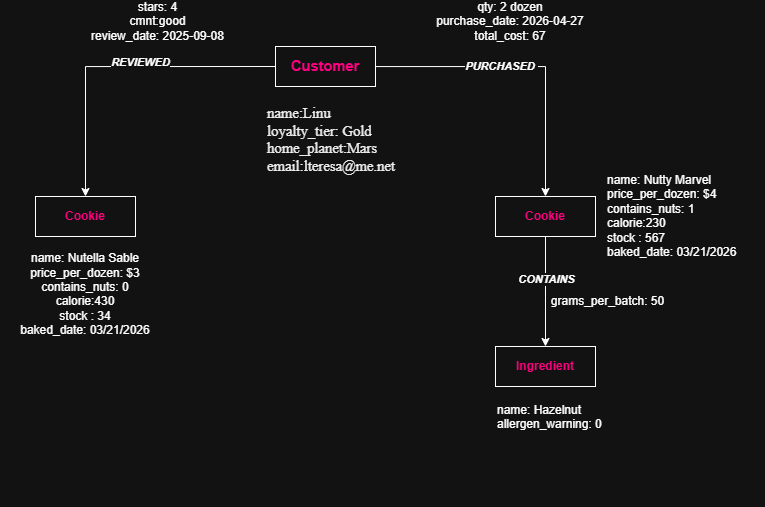

#4&rpar; Graph creation

Using `neo4j` python package.

In [ ]:
from neo4j import GraphDatabase

uri = "bolt://localhost:7687"
username = "neo4j"
password =  pwd
driver = GraphDatabase.driver(uri, auth=(username, password))



In [ ]:
delete_all_query = """
MATCH (n) DETACH DELETE n;
"""

create_nodes_and_relationships_query = """
CREATE
(c1:Customer {name: 'Leenew', loyalty_tier: 'Gold', home_planet: 'Earth', email: 'linu@earth.com'}),
(c2:Customer {name: 'TaeHyung', loyalty_tier: 'Silver', home_planet: 'Venus', email: 'tatetea@ij.com'}),
(c3:Customer {name: 'JoIly', loyalty_tier: 'Gold', home_planet: 'Titan', email: 'jollymonejolly@abcd.com'}),

(p1:Cookie {flavor_name: 'Black-Hole Brownie', price_per_dozen: 24.0, contains_nuts: false, calories: 450}),
(p2:Cookie {flavor_name: 'Nebula Nutella Sablé', price_per_dozen: 28.0, contains_nuts: true, calories: 320}),
(p3:Cookie {flavor_name: 'Macaron de Mars', price_per_dozen: 30.0, contains_nuts: true, calories: 200}),

(i1:Ingredient {ingredient_name: 'Galactic Hazelnuts', supplier_planet: 'Jupiter', allergen_warning: true}),
(i2:Ingredient {ingredient_name: 'Space Cocoa', allergen_warning: false}),
(i3:Ingredient {ingredient_name: 'Almond Flour', allergen_warning: true}),

(c1)-[:PURCHASED {purchase_date: '2026-03-25', qty: 2, total_cost: 48.0}]->(p1),
(c1)-[:REVIEWED {stars: 5, comment: 'Dark and dense like a real black hole!', review_date: '2026-03-26'}]->(p1),
(c1)-[:PURCHASED {purchase_date: '2026-03-28', qty: 1, total_cost: 28.0}]->(p2),

(c2)-[:PURCHASED {purchase_date: '2026-03-29', qty: 3, total_cost: 84.0}]->(p2),
(c2)-[:REVIEWED {stars: 4, comment: 'Good, but a bit too sweet.', review_date: '2026-03-30'}]->(p2),

(c3)-[:PURCHASED {purchase_date: '2026-03-30', qty: 1, total_cost: 30.0}]->(p3),
(c3)-[:PURCHASED {purchase_date: '2026-03-30', qty: 1, total_cost: 24.0}]->(p1),

(p1)-[:CONTAINS {grams_per_batch: 500}]->(i2),
(p2)-[:CONTAINS {grams_per_batch: 250}]->(i1),
(p2)-[:CONTAINS {grams_per_batch: 100}]->(i2),
(p3)-[:CONTAINS {grams_per_batch: 300}]->(i3)
"""

with driver.session() as session:
  session.run(delete_all_query)
  session.run(create_nodes_and_relationships_query)
  print(" Le cookie Quantique graph created successfully with 9 nodes and 11 edges.")

 Le cookie Quantique graph created successfully with 9 nodes and 11 edges.


#5&rpar; Graph query (operational)

##5.1 Questions to be answered and how is it relevant to Le Cookie Quantique

I want to ask : " Which other cookies are frequently purchased by customers who bought the Black-Hole Brownie? "

This is highly powerful for the business as it helps to set up a real-time recommendation engine on the storefront to drive upselling and increasing average order value.

##5.2 How does your query make use of the fact that this is a graph?

This query will take full advantage of index- free adjacency. In realtional SQL database answering "customer who bought X also bought Y", requires highly intensive, slow JOIN operations across Customer, Orders and OrderItems tables multiple times.

In my cypher query, Neo4j would start at the Brownie node, hops abckwards along the PURCHASED edges to find the specific customers, and then hop forward along those customers' other PURCHASED edges. Because these physical memory pointers already exists, the database can traverse this path and return a recommnedation quickly, regardlesso of the size of the database.

Running the cypher query to answer the above question ...

In [ ]:

recommendation_query = """
MATCH (target:Cookie {flavor_name: 'Black-Hole Brownie'})
<-[:PURCHASED]-(c:Customer)-[:PURCHASED]->(rec:Cookie)
RETURN rec.flavor_name AS Recommended_Cookie, COUNT(c) AS Buyers_In_Common
ORDER BY Buyers_In_Common DESC
"""

print("--- 🍪 Real-Time Cookie Recommendations ---")
print("Customers who bought the 'Black-Hole Brownie' also bought:\n")

with driver.session() as session:
    result = session.run(recommendation_query)
    for record in result:
        print(f"-> {record['Recommended_Cookie']} (Bought by {record['Buyers_In_Common']} matching customers)")

--- 🍪 Real-Time Cookie Recommendations ---
Customers who bought the 'Black-Hole Brownie' also bought:

-> Macaron de Mars (Bought by 1 matching customers)
-> Nebula Nutella Sablé (Bought by 1 matching customers)


#6&rpar; Graph Analysis (Analytical)

Loading the built-in LastFM dataset from Graph Data Science (GDS),

In [ ]:
from graphdatascience import GraphDataScience

uri = "bolt://localhost:7687"
username = "neo4j"
gds = GraphDataScience(uri, auth=(username, pwd))

In [ ]:

if gds.graph.exists('lastfm')['exists']:
    gds.graph.get('lastfm').drop()

G = gds.graph.load_lastfm()

print("\nDataset Loaded Successfully!")
print(f"● Graph Name: {G.name()}")
print(f"● Node count: {G.node_count():,}")
print(f"● Node labels: {G.node_labels()}")
print(f"● Edge types: {G.relationship_types()}")
print(f"● Relationship count: {G.relationship_count():,}")


Dataset Loaded Successfully!
● Graph Name: lastfm
● Node count: 19,914
● Node labels: ['Artist', 'User']
● Edge types: ['TAGGED', 'IS_FRIEND', 'LISTEN_TO']
● Relationship count: 584,060


##6.1 Centrality in this graph

###6.1.1 How might you find the most popular Artist node in this sample graph?
To find the most popular artist, I would calculate the Degree Centrality (specifically In-Degree) for all nodes with the Artist label. This counts the number of incoming `LISTEN_TO `edges originating from User nodes. The artist with the highest degree score is the most popular.

###6.1.2 What does degree centrality tell you about this node?
In the LastFM dataset, a node's degree centrality tells us the exact number of unique users who have listened to that specific artist. It is a direct, hard metric of their broad popularity across the user base.


### 6.3.1 Using the Graph Data Science library (degree centrality),  to find the most popular node in this sample dataset.

In [ ]:
centrality_results = gds.degree.stream(G)
top_node  = centrality_results.sort_values(by="score",ascending=False).iloc[0]
print(f" Most popular Node id : {top_node['nodeId']}")
print(f"Total Connections (Degree Score): {top_node['score']}")

 Most popular Node id : 1672.0
Total Connections (Degree Score): 2660.0


#7&rpar; Implementing graph algorithm - USE CASE -> Page Rank

In [ ]:
pagerank_results = gds.pageRank.stream(G)
top_influencers = pagerank_results.sort_values(by="score",ascending=False).head(3)
print("\n--- Top 3 Most Influential Nodes (PageRank) ---")
print(top_influencers)

 PageRank:   7%|6         | 6.72/100 [00:00<?, ?%/s]


--- Top 3 Most Influential Nodes (PageRank) ---
      nodeId      score
1139    1249  75.590157
1509    1672  67.899900
1740    1929  59.591963


##7.1 What the algorithm did?

I ran the PageRank algorithm against the LastFM dataset. While Degree Centrality simply counts raw connections, PageRank calculates the transitive influence of a node. It assumes that a connection from a highly influential node is more valuable than a connection from a node with few connections. By running this, I was trying to find the nodes that act as the most significant "hubs" in the network, taking the entire graph's topology into account rather than just local popularity.

#8&rpar; Machine learning task


In [ ]:
if gds.pipeline.exists("lastfm_lp_pipeline")['exists']:
    gds.pipeline.get("lastfm_lp_pipeline").drop()


if gds.model.exists("lastfm_lp_model")['exists']:
    gds.model.get("lastfm_lp_model").drop()

pipe, _ = gds.beta.pipeline.linkPrediction.create("lastfm_lp_pipeline")
pipe.addNodeProperty("fastRP", mutateProperty="embedding", embeddingDimension=64, randomSeed=42)
pipe.addFeature("hadamard", nodeProperties=["embedding"])
pipe.addLogisticRegression(maxEpochs=10)

model, stats = pipe.train(
    G,
    modelName="lastfm_lp_model",
    concurrency=4,
    targetRelationshipType="LISTEN_TO",
    randomSeed=42
)

test_aucpr = stats['modelInfo']['metrics']['AUCPR']['test']
print(f"Training Complete!")
print(f"Area Under the Precision-Recall Curve (Test Data): {test_aucpr:.4f}")

Training Complete!
Area Under the Precision-Recall Curve (Test Data): 0.8717


##8.1 What did the algorithm do?

I chose to perform Link Prediction, a supervised ML task perfect for the LastFM dataset. The goal is to predict new `LISTEN_TO` relationships,
essentially building a recommendation engine that predicts which artists a user will listen to next.

I created a GDS pipeline that generates FastRP node embeddings to capture the graph's structure. I combined these embeddings using the Hadamard product to create edge features, and trained a Logistic Regression classifier on the existing data.



##8.2 Results
The model returned an AUCPR (Area Under the Precision-Recall Curve) score. A score closer to 1.0 indicates that the model is highly accurate at predicting true LISTEN_TO links while minimizing false positives, proving the graph topology holds strong predictive power for user behavior.



#9&rpar; Dive into a data science topic or tool that interests you and is related to graph databases.


##9.1 Why did I choose the topic and how it relates to graph databases.

The topic I am choosing in graphRAG, I chose this topic out of pure curiosity, I wanted to dig deeper and see how using graphs help/affects LLM to solve problems.

Perhaps the greatest challenge and opportunity  of LLMs is extending their powerful capabilities to solve problems beyond the data on which they have been trained, and to achieve comparable results with data the LLM has never seen. This opens new possibilities in data investigation, such as identifying themes and semantic concepts with context and grounding on datasets. This gap in RAGs can be bridged using Graph Databases.


##9.2 How it works? And how to use it in the real world?

Traditional RAG systems retrieve document chunks based on semantic similarity, which works well for straightforward questions. But when queries require synthesizing information scattered across multiple documents or reasoning through connected concepts, vector search falls short. The system retrieves fragments without understanding how they relate to each other.

GraphRAG doesn't treat documents as isolated chunks. It builds a knowledge graph that captures entities and their relationships. This structure allows the system to traverse connections and answer questions that require pulling together information from multiple sources.

How GraphRAG Works?


1. Graph creation: An LLM processes the entire dataset to identify "entities" (people, places, organizations) and the "relationships" between them. These entities and relationships are used to build a knowledge graph.

2.  Community Detection (Clustering): The system uses graph machine learning to organize the data into "semantic clusters" (groups of related information).

3. Pre-Summarization: The LLM generates summaries for these clusters at different levels of detail.

4. Query-Time Retrieval: When we ask a question, the system searches both the original text and these pre-summarized "communities" to provide a holistic answer with provenance (source grounding).

When can it be useful for us?

GraphRAG is particularly powerful when you need to understand the "big picture" of a dataset rather than just finding a needle in a haystack.

example : When you need to understand the main themes and sentiment clusters across millions of posts or comments in Social media.

or summarizing thousands of business documents to find the "top 5 recurring mistakes".

##9.3 The other side of this coin (tradeoffs or pitfalls)

Below are some of the tradeoffs with implementing grapgRAG.

*   High Costs: Building the graph requires extensive LLM calls for entity extraction and relationship mapping, making it significantly more expensive than standard Vector RAG.
*   High Latency: Global search and complex graph traversals often take 20–60+ seconds, which can be too slow for real-time user applications.

*  Incremental Update Issues: It is technically difficult and costly to add new data to an existing graph without re-processing large sections of the network.



##9.4 What did I learn?

What I found most surprising is the architectural irony of the GraphRAG pipeline itself. We are essentially using a highly probabilistic, unstructured tool (an LLM) to forcefully extract and build a deterministic, highly structured asset. We then turn around and use that rigid graph structure to prevent the LLM from hallucinating.

Furthermore, having just implemented vector similarity search, it was fascinating to see the distinct boundaries of these technologies. Vector embeddings are perfect for finding a needle in a haystack that is the exact semantic match, but GraphRAG is necessary when you need to understand the haystack itself, how all the individual pieces of data connect to form broader, overarching themes.